# PROJET ML — CLASSIFICATION DE VIDÉOS YOUTUBE *TRENDING*

**Dataset Kaggle**: https://www.kaggle.com/datasets/datasnaek/youtube-new

**Objectif**: Développer un classificateur pour prédire si une vidéo YouTube deviendra *trending*.

> Ce notebook est conçu pour être complété. Chaque section contient des consignes détaillées et des zones de code à compléter.


## 1. Importation des librairies

**Consigne 1.1 — Importez toutes les librairies nécessaires**
- `pandas`, `numpy` pour la manipulation de données  
- `matplotlib.pyplot`, `seaborn` pour la visualisation  
- `sklearn` pour le machine learning  
- `warnings` pour supprimer les avertissements

In [1]:
# VOTRE CODE ICI - Section 1.1
# import pandas as pd
# import numpy as np ....
#...
#...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import os
# Suppression des warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement et exploration des données

**Consigne 2.1 — Chargement des données**
- Chargez le fichier `USvideos.csv` avec pandas  
- Affichez les 5 premières lignes  
- Affichez les informations générales (`info()`, `shape`, `describe()`)

*Aide* :
- Utilisez `pd.read_csv()` avec `encoding='utf-8'`
- `.info()` donne les types de colonnes et valeurs non-nulles
- `.describe()` donne les statistiques descriptives

In [2]:
# Récupération des données via Kaggle
import kagglehub
import shutil

path_projet = 'dataset'

if os.path.exists(path_projet) and any(f.endswith(('.csv', '.json')) and os.path.isfile(os.path.join(path_projet, f)) for f in os.listdir(path_projet)):
    print(f'Fichiers présents dans {path_projet}')
else:
    # Téléchargement du dataset dans un chemin provisoire
    path_temp = kagglehub.dataset_download("datasnaek/youtube-new")

    # Création du dossier "dataset"
    path_projet = os.path.join(os.getcwd(), "dataset")
    os.makedirs(path_projet, exist_ok=True)

    # Déplacement du dataset dans le dossier "dataset"
    dataset_name = os.path.basename(path_temp)
    path_dataset = os.path.join(path_projet, dataset_name)
    shutil.move(path_temp, path_dataset)

    print("Chemin du fichier dataset :", path_projet)

    # Récupération du chemin du sous dossier
    sous_dossier = os.path.join(path_projet, os.listdir(path_projet)[0])

    # Boucle dans le sous dossier pour ne garder que les fichiers de data qui nous intéresse (ici doit commencer par "US")
    for fichier in os.listdir(sous_dossier):
        path_fichier = os.path.join(sous_dossier, fichier)
        if os.path.isfile(path_fichier):
            if not fichier.startswith("US"):    
                os.remove(path_fichier)
                print(f"Fichier {fichier} supprimé.")
            else:
                print(f"Fichier {fichier} conservé.")

    # Boucle sur les fichiers conservés pour les déplacer dans le dossier "dataset"
    for fichier in os.listdir(sous_dossier):
        path_fichier = os.path.join(sous_dossier, fichier)
        if os.path.isfile(path_fichier):
            shutil.move(path_fichier, path_projet)
            print(f"Fichier {fichier} déplacé vers {path_projet}")

    # Supprime le sous dossier vide
    os.rmdir(sous_dossier)
    print(f"Dossier {sous_dossier} supprimé.")

    print("Opération terminée. Fichiers disponibles dans :", path_projet)

Fichiers présents dans dataset


In [3]:
# VOTRE CODE ICI - Section 2.1
# import pandas as pd
# df = pd.read_csv('USvideos.csv', encoding='utf-8')
# print("Premières lignes:")
# display(...())
# print("\nInformations générales:")
# display(...())
# print("Shape:", ....)
# display(df.describe(include='all').transpose())

# Chargement du fichier
df = pd.read_csv("dataset/USvideos.csv", encoding="utf-8")

# Affichage des 5 premières lignes
print("Premières lignes :")
display(df.head())

# Informations générales
print("\nInformations générales :")
display(df.info())

# Dimensions du DataFrame
print("\nShape :", df.shape)

# Statistiques descriptives
print("\nStatistiques descriptives :")
display(df.describe(include="all").transpose())

Premières lignes :


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...



Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  4094

None


Shape : (40949, 16)

Statistiques descriptives :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,40949,6351,j4KvrAUjn6c,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,40949,205,17.14.11,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,40949,6455,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,40949,2207,ESPN,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,40949.0,NaN,NaN,NaN,19.972429,7.568327,1.0,17.0,24.0,25.0,43.0
publish_time,40949,6269,2018-05-18T14:00:04.000Z,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,40949,6055,[none],1535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,40949.0,NaN,NaN,NaN,2360784.638257,7394113.759704,549.0,242329.0,681861.0,1823157.0,225211923.0
likes,40949.0,NaN,NaN,NaN,74266.702435,228885.338209,0.0,5424.0,18091.0,55417.0,5613827.0
dislikes,40949.0,NaN,NaN,NaN,3711.400889,29029.705945,0.0,202.0,631.0,1938.0,1674420.0


**Consigne 2.2 — Analyse des valeurs manquantes**  
- Comptez les valeurs manquantes par colonne  
- Identifiez les colonnes avec le plus de valeurs manquantes  
- Affichez le pourcentage de valeurs manquantes

In [4]:
# VOTRE CODE ICI - Section 2.2
# missing = df...
# pct_missing = (missing / len(df)) * 100
# print("Valeurs manquantes (nombre):")
# display(....))
# print("\nValeurs manquantes (pourcentage):")
# display(...))

# Compter les valeurs manquantes par colonne
missing = df.isnull().sum()

# Calculer le pourcentage de valeurs manquantes
pct_missing = (missing / len(df)) * 100

# Afficher les valeurs manquantes (nombre)
print("Valeurs manquantes (nombre) :")
display(missing.sort_values(ascending=False))

# Afficher les valeurs manquantes (pourcentage)
print("\nValeurs manquantes (pourcentage) :")
display(pct_missing.sort_values(ascending=False))

Valeurs manquantes (nombre) :


description               570
video_id                    0
title                       0
trending_date               0
category_id                 0
publish_time                0
tags                        0
channel_title               0
views                       0
likes                       0
comment_count               0
dislikes                    0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
dtype: int64


Valeurs manquantes (pourcentage) :


description               1.391975
video_id                  0.000000
title                     0.000000
trending_date             0.000000
category_id               0.000000
publish_time              0.000000
tags                      0.000000
channel_title             0.000000
views                     0.000000
likes                     0.000000
comment_count             0.000000
dislikes                  0.000000
thumbnail_link            0.000000
comments_disabled         0.000000
ratings_disabled          0.000000
video_error_or_removed    0.000000
dtype: float64

**Consigne 2.3 — Exploration des catégories**  
- Chargez le fichier JSON des catégories (`US_category_id.json`)  
- Fusionnez avec le DataFrame principal  
- Affichez la distribution des catégories

*Aide* : La structure JSON est du type:  
`{"items": [{"id": "1", "snippet": {"title": "Film & Animation"}}, ...]}`

In [5]:
# VOTRE CODE ICI - Section 2.3
# import pandas as pd
# import json
# categories_raw = read-json...
# items = categories_raw['items'].tolist()
# category_dict = {int(item['id']): item['snippet']['title'] for item in items}
# cat_df = pd.DataFrame(list(category_dict.items()), columns=['category_id', 'category_title'])
# df_merged = df.merge(cat_df, how='left', left_on='category_id', right_on='category_id')
# print("Distribution des catégories:")
# display(df_merged['category_title'].value_counts().to_frame('count'))

import json

# Chargement du json
with open("dataset/US_category_id.json") as f:
    categories_raw = json.load(f)

# On récupère la liste des catégories dans le json
items = categories_raw['items']

# On construit un dictionnaire
category_dict = {int(item['id']): item['snippet']['title'] for item in items}

# On convertit ce dictionnaire en DataFrame
cat_df = pd.DataFrame(list(category_dict.items()), columns=['category_id', 'category_title'])

# On fusionne le df avec le DataFrame des catégories
df_merged = df.merge(cat_df, how='left', left_on='category_id', right_on='category_id')

print("Distribution des catégories:")
display(df_merged['category_title'].value_counts().to_frame('count'))

Distribution des catégories:


,count
category_title,
Entertainment,9964
Music,6472
Howto & Style,4146
Comedy,3457
People & Blogs,3210
News & Politics,2487
Science & Technology,2401
Film & Animation,2345
Sports,2174


## 3. Nettoyage des données

**Consigne 3.1 — Nettoyage des données**
- Supprimez les doublons basés sur `video_id`  
- Gérez les valeurs manquantes dans `description` (remplacez par string vide)  
- Convertissez `publish_time` en datetime  
- Supprimez les lignes avec des valeurs aberrantes (ex: `views` négatives)

In [6]:
# VOTRE CODE ICI - Section 3.1
# df_clean = df.drop_duplicates(subset='video_id').copy()
# df_clean['description'] = ....
# import pandas as pd
# df_clean['publish_time'] = ().... errors='coerce')
# df_clean = df_clean[(df_clean['views'] >= 0) & (df_clean['likes'] >= 0) & (df_clean['dislikes'] >= 0) & (df_clean['comment_count'] >= 0)]
# df_clean = df_clean.dropna(subset=['publish_time'])

# On supprime les doublons en gardant seulement une ligne par 'video_id'
df_clean = df.drop_duplicates(subset='video_id').copy()

# On merge avec les catégories
df_clean = df_clean.merge(cat_df, how='left', left_on='category_id', right_on='category_id')

# On remplace les valeurs manquantes (NaN) dans la colonne 'description' par une chaîne vide ""
df_clean['description'] = df_clean['description'].fillna("")

# On convertit la colonne 'publish_time' en format datetime
df_clean['publish_time'] = pd.to_datetime(df_clean['publish_time'], errors='coerce').dt.tz_localize(None)

# On filtre le DataFrame pour ne garder que les vidéos avec des valeurs positives ou nulles
df_clean = df_clean[(df_clean['views'] >= 0) & (df_clean['likes'] >= 0) & (df_clean['dislikes'] >= 0) & (df_clean['comment_count'] >= 0)]

# On supprime les lignes où 'publish_time' est manquant (NaT après conversion)
df_clean = df_clean.dropna(subset=['publish_time'])

display(df_clean.info())
display(df_clean['category_title'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6351 entries, 0 to 6350
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   video_id                6351 non-null   object        
 1   trending_date           6351 non-null   object        
 2   title                   6351 non-null   object        
 3   channel_title           6351 non-null   object        
 4   category_id             6351 non-null   int64         
 5   publish_time            6351 non-null   datetime64[ns]
 6   tags                    6351 non-null   object        
 7   views                   6351 non-null   int64         
 8   likes                   6351 non-null   int64         
 9   dislikes                6351 non-null   int64         
 10  comment_count           6351 non-null   int64         
 11  thumbnail_link          6351 non-null   object        
 12  comments_disabled       6351 non-null   bool    

None

category_title
Entertainment            1619
Music                     799
Howto & Style             595
Comedy                    547
News & Politics           505
People & Blogs            498
Sports                    451
Science & Technology      380
Film & Animation          318
Education                 250
Pets & Animals            138
Gaming                    103
Autos & Vehicles           70
Travel & Events            60
Nonprofits & Activism      14
Shows                       4
Name: count, dtype: int64

## 4. Feature Engineering

**Consigne 4.1 — Variables d'engagement**
** définition : https://support.google.com/youtube/answer/2991785?hl=fr**

In [7]:
# VOTRE CODE ICI - Section 4.1
# import numpy as np
# eps = 1e-9
# denom = df_clean['likes'] + df_clean['dislikes']
# df_clean['like_ratio'] = np.where(denom > 0, df_clean['likes'] / denom, 0)
# df_clean['engagement_rate'] = np.where(df_clean['views'] > 0,
#                                        (df_clean['likes'] + df_clean['dislikes'] + df_clean['comment_count']) / (df_clean['views'] + eps),
#                                        0)
# df_clean['comments_per_view'] = np.where(df_clean['views'] > 0, df_clean['comment_count'] / (df_clean['views'] + eps), 0)

# On définit une très petite valeur pour éviter la division par zéro
eps = 1e-9

# On défini la date de référence (fin du dataset clean)
ref_date = pd.Timestamp('2018-06-13')

# On calcule l'âge de la vidéo en jours jusqu'à la date de référence (date de fin du dataset)
df_clean['age_days'] = (ref_date - df_clean['publish_time']).dt.days.clip(lower=1)

# On calcule le nombre de : vues, likes et commentaires par jour
df_clean['views_per_day'] = df_clean['views'] / df_clean['age_days']
df_clean['likes_per_day'] = df_clean['likes'] / df_clean['age_days']
df_clean['comments_per_day'] = df_clean['comment_count'] / df_clean['age_days']

# On calcule le dénominateur pour le ratio de likes : likes + dislikes
denom = df_clean['likes'] + df_clean['dislikes']

# On calcule le ratio de likes et dislikes ainsi que la balance entre les deux
df_clean['like_ratio'] = np.where(denom > 0, df_clean['likes'] / denom, 0)
df_clean['dislike_ratio'] = np.where(denom > 0, df_clean['dislikes'] / denom, 0)
df_clean['like_dislike_balance'] = np.where(denom > 0, (df_clean['likes'] - df_clean['dislikes']) / denom, 0)

# On calcule le taux d'engagement global 'engagement_rate'
df_clean['engagement_rate'] = np.where(df_clean['views'] > 0, (df_clean['likes'] + df_clean['dislikes'] + df_clean['comment_count']) / (df_clean['views'] + eps), 0)

# On calcule le ratio de commentaires par vues et par likes
df_clean['comment_per_view'] = np.where(df_clean['views'] > 0, df_clean['comment_count'] / (df_clean['views'] + eps), 0)
df_clean['comments_per_like'] = np.where(df_clean['likes'] > 0, df_clean['comment_count'] / (df_clean['likes'] + eps), 0)


**Consigne 4.2 — Variables temporelles**

In [8]:
# VOTRE CODE ICI - Section 4.2
# df_clean['publish_hour'] = ....
# df_clean['publish_day_of_week'] = ...
# df_clean['publish_month'] = ...

df_clean['publish_hour'] = df_clean['publish_time'].dt.hour
df_clean['publish_day_of_week'] = df_clean['publish_time'].dt.dayofweek
df_clean['publish_month'] = df_clean['publish_time'].dt.month
df_clean['publish_year'] = df_clean['publish_time'].dt.year

display(df_clean)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,like_ratio,dislike_ratio,like_dislike_balance,engagement_rate,comment_per_view,comments_per_like,publish_hour,publish_day_of_week,publish_month,publish_year
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,...,0.950970,0.049030,0.901939,0.102151,0.021318,0.277331,17,0,11,2017
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,...,0.940521,0.059479,0.881042,0.047972,0.005252,0.130709,7,0,11,2017
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,...,0.964729,0.035271,0.929459,0.049994,0.002563,0.056022,19,6,11,2017
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,...,0.938550,0.061450,0.877099,0.037836,0.006253,0.210971,11,0,11,2017
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,...,0.985181,0.014819,0.970363,0.072405,0.008359,0.132476,18,6,11,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6346,dS5Thrl-4Kc,18.14.06,CRAYOLA MAKEUP | HIT OR MISS?,Laura Lee,26,2018-06-12 18:55:26,"Laura88Lee|""crayola""|""crayon makeup""|""crayola ...",607422,26166,895,...,0.966927,0.033073,0.933853,0.050341,0.005790,0.134411,18,1,6,2018
6347,JGm9Y_hFqNk,18.14.06,First Take reacts: Kyrie Irving says contract ...,ESPN,17,2018-06-13 15:06:08,"espn|""espn live""|""boston celtics""|""kyrie irvin...",812832,7701,320,...,0.960105,0.039895,0.920209,0.012950,0.003082,0.325282,15,2,6,2018
6348,6h8QgZF5Qu4,18.14.06,Drop the Mic w/ Ashton Kutcher & Sean Diddy Combs,The Late Late Show with James Corden,24,2018-06-13 05:27:27,"The Late Late Show|""Late Late Show""|""James Cor...",864189,18811,399,...,0.979230,0.020770,0.958459,0.023472,0.001243,0.057094,5,2,6,2018
6349,mpnshdmtE2Y,18.14.06,Carla Makes BA Smashburgers | From the Test Ki...,Bon Appétit,26,2018-06-12 16:03:58,"bon appetit|""burgers""|""cheeseburgers""|""how to ...",540149,14206,693,...,0.953487,0.046513,0.906974,0.029825,0.002242,0.085246,16,1,6,2018


**Consigne 4.3 — Variables textuelles (titre)**

In [9]:
# VOTRE CODE ICI - Section 4.3
# df_clean['title_length'] = ...
# df_clean['title_word_count'] = ....
# df_clean['has_caps'] = ...
# df_clean['has_numbers'] = ...

df_clean['title_length'] = df_clean['title'].str.len()
display(df_clean['title_length'])
print(df_clean['title_length'])

df_clean['title_word_count'] = df_clean['title'].str.split().str.len()
print(df_clean['title_word_count'])

df_clean['has_cap'] = df_clean['title'].str.contains(r'[A-Z]')
print(df_clean['has_cap'])

df_clean['has_numbers'] = df_clean['title'].str.contains(r'[\d]')
print(df_clean['has_numbers'])

print(df_clean.shape)

0       34
1       62
2       53
3       32
4       24
        ..
6346    29
6347    94
6348    49
6349    65
6350    64
Name: title_length, Length: 6351, dtype: int64

0       34
1       62
2       53
3       32
4       24
        ..
6346    29
6347    94
6348    49
6349    65
6350    64
Name: title_length, Length: 6351, dtype: int64
0        7
1       10
2       10
3        5
4        5
        ..
6346     6
6347    16
6348    10
6349    12
6350    10
Name: title_word_count, Length: 6351, dtype: int64
0       True
1       True
2       True
3       True
4       True
        ... 
6346    True
6347    True
6348    True
6349    True
6350    True
Name: has_cap, Length: 6351, dtype: bool
0       False
1       False
2       False
3       False
4       False
        ...  
6346    False
6347    False
6348    False
6349    False
6350     True
Name: has_numbers, Length: 6351, dtype: bool
(6351, 35)


## 5. Création de la variable cible

**Consigne 5.1 — Définition de `is_trending`**  
- Une vidéo est *trending* si elle a plus de vues que le 80e percentile de sa catégorie

In [10]:
# VOTRE CODE ICI - Section 5.1
# df_clean['is_trending'] = (df_clean.groupby('category_id')['views']
#                                   .transform(lambda x: x > x.quantile(0.8))).astype(int)
# print("Distribution de la variable cible:")
# display(df_clean['is_trending'].value_counts().to_frame('count'))

df_clean['is_trending'] = (df_clean.groupby('category_id')['views'].transform(lambda x: x > x.quantile(0.8))).astype(int)

print('Distribution de la variable cible:')
display(df_clean['is_trending'].value_counts().to_frame('count'))

Distribution de la variable cible:


,count
is_trending,
0,5078
1,1273


## 5.Bis Visualisations

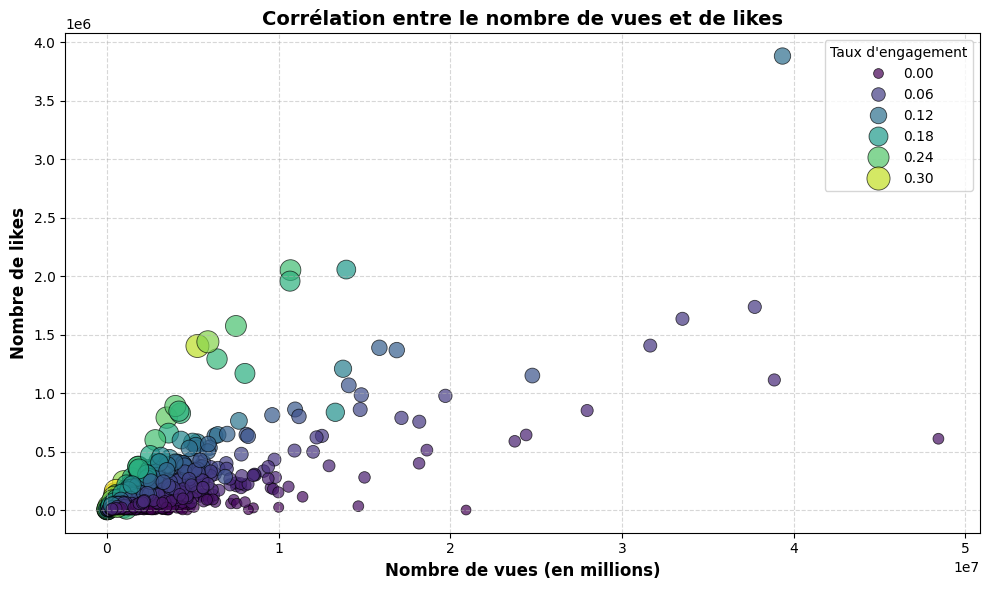

In [11]:
plt.figure(figsize=(10,6))  # agrandir le graphique

sns.scatterplot(
    data=df_clean,
    x='views',
    y='likes',
    hue='engagement_rate',
    palette='viridis',     # palette plus lisible
    size='engagement_rate',# taille proportionnelle au taux d'engagement
    sizes=(50, 300),       # plage de tailles
    alpha=0.7,             # transparence pour éviter la superposition
    edgecolor="k"          # contour noir pour distinguer les points
)

plt.xlabel("Nombre de vues (en millions)", fontsize=12, fontweight="bold")
plt.ylabel("Nombre de likes", fontsize=12, fontweight="bold")
plt.title("Corrélation entre le nombre de vues et de likes", fontsize=14, fontweight="bold")
plt.legend(title="Taux d'engagement")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


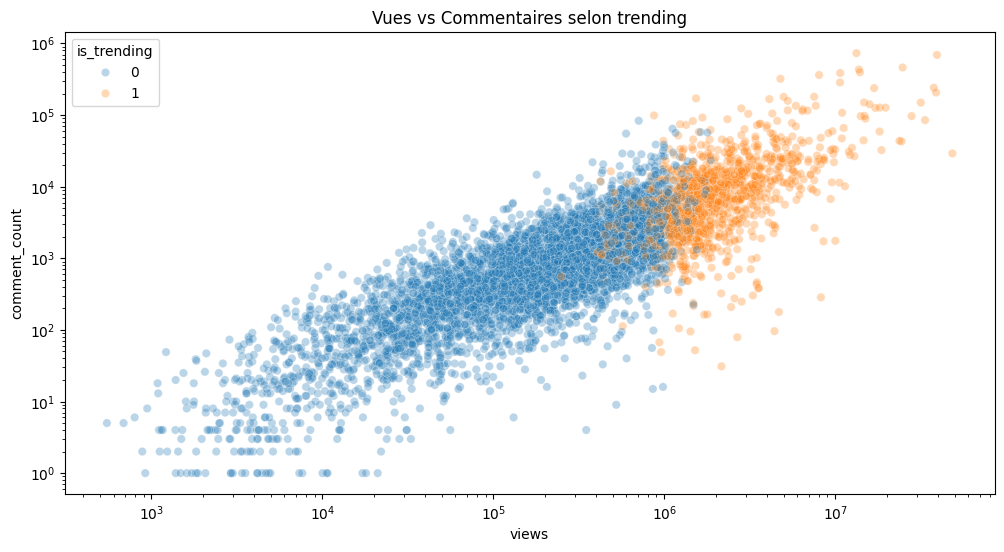

In [12]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_clean, x="views", y="comment_count",
    hue="is_trending", alpha=0.3
)
plt.xscale("log")
plt.yscale("log")
plt.title("Vues vs Commentaires selon trending")
plt.show()


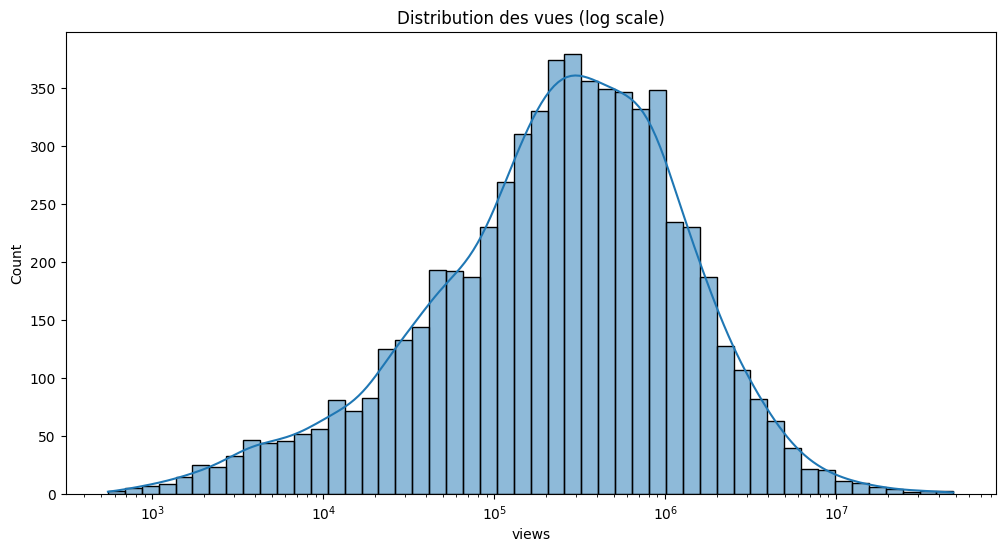

In [13]:
plt.figure(figsize=(12, 6))
sns.histplot(df_clean["views"], bins=50, log_scale=True, kde=True)
plt.title("Distribution des vues (log scale)")
plt.show()

## 6. Préparation des données pour l'entraînement

**Consignes 6.1 & 6.2 — Sélection des features & split train/test**

In [14]:
# VOTRE CODE ICI - Section 6.1 et 6.2
# features = ['views', 'likes', 'dislikes', 'comment_count',
#             'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']
# X = df_clean[features].copy()
# y = df_clean['is_trending'].copy()
#.......
# ......

# print(f"Taille train: {X_train.shape}")
# print(f"Taille test: {X_test.shape}")

from sklearn.model_selection import train_test_split

# Sélection des features
features = ['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'engagement_rate', 'title_length', 'publish_hour', 'category_id']

x = df_clean[features].copy()
y = df_clean['is_trending'].copy()

# Split train/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Taille de train : {x_train.shape}')
print(f'Taille de test : {x_test.shape}')

Taille de train : (5080, 9)
Taille de test : (1271, 9)


**Consigne 6.3 — Normalisation des données (StandardScaler)**

In [15]:
# VOTRE CODE ICI - Section 6.3
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# num_cols = ['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'engagement_rate', 'title_length', 'publish_hour']
# # Fit uniquement sur train
# ....
# ...
# ....
# ....
# ....

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'engagement_rate', 'title_length', 'publish_hour']

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

print('Moyenne train : \n \n', x_train[num_cols].mean())
print('\n', '-'*30,'\n')
print('Ecart-type train : \n \n', x_train[num_cols].std())

Moyenne train : 
 
 views             -2.797412e-18
likes             -2.272898e-17
dislikes           4.196119e-18
comment_count      6.993531e-18
like_ratio         9.287409e-16
engagement_rate   -6.154307e-17
title_length       1.349751e-16
publish_hour       1.468641e-16
dtype: float64

 ------------------------------ 

Ecart-type train : 
 
 views              1.000098
likes              1.000098
dislikes           1.000098
comment_count      1.000098
like_ratio         1.000098
engagement_rate    1.000098
title_length       1.000098
publish_hour       1.000098
dtype: float64


## 7. Modèle 1 — Random Forest

**Consigne 7.1 — Entraînement**

In [16]:
# VOTRE CODE ICI - Section 7.1
# from sklearn.ensemble import RandomForestClassifier
# ....
# ....
# ....

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, max_features='sqrt', random_state=0, class_weight='balanced')

rf_model.fit(x_train, y_train)

print(y.value_counts(normalize=True))

# Évaluation sur le test set
rf_predictions = rf_model.predict(x_test)

is_trending
0    0.799559
1    0.200441
Name: proportion, dtype: float64


In [ ]:
# def generate_random_video(df_clean, scaler):
#     """    
#     Génère un DataFrame d'une vidéo aléatoire avec les mêmes colonnes que le training set.
#     Applique le scaler sur les colonnes numériques si nécessaire.
#     """

#     new_video_raw = pd.DataFrame({
#         'views': [np.random.randint(df_clean['views'].min(), df_clean['views'].max())],
#         'likes': [np.random.randint(df_clean['likes'].min(), df_clean['likes'].max())],
#         'dislikes': [np.random.randint(df_clean['dislikes'].min(), df_clean['dislikes'].max())],
#         'comment_count': [np.random.randint(df_clean['comment_count'].min(), df_clean['comment_count'].max())],
#         'like_ratio': [np.random.uniform(df_clean['like_ratio'].min(), df_clean['like_ratio'].max())],
#         'engagement_rate': [np.random.uniform(df_clean['engagement_rate'].min(), df_clean['engagement_rate'].max())],
#         'title_length': [np.random.randint(df_clean['title_length'].min(), df_clean['title_length'].max())],
#         'publish_hour': [np.random.randint(df_clean['publish_hour'].min(), df_clean['publish_hour'].max())],
#         'category_id': [np.random.choice(df_clean['category_id'].unique())]
#     })

#     new_video_scaled = new_video_raw.copy()
#     new_video_scaled[num_cols] = scaler.transform(new_video_scaled[num_cols])
#     return new_video_raw, new_video_scaled

# random_video_raw, random_video_scaled = generate_random_video(x, scaler)

# print("Nouvelle vidéo générée (valeurs brutes) :\n", random_video_raw)
# print("Nouvelle vidéo (après scaling) :\n", random_video_scaled)
# print("Prédiction is_trending :", rf_model.predict(random_video_scaled))

**Consigne 7.2 — Évaluation**

In [17]:
# VOTRE CODE ICI - Section 7.2
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# print("Random Forest - Résultats:")
# print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
# print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")
# print(f"Recall: {recall_score(y_test, rf_predictions):.4f}")
# print(f"F1-Score: {f1_score(y_test, rf_predictions):.4f}")
# # Importance des variables
# import pandas as pd
# feature_importance = pd.DataFrame({
#     'feature': X.columns,
#     'importance': rf_model.feature_importances_
# }).sort_values('importance', ascending=False)
# print("\nTop 10 variables importantes:")
# display(feature_importance.head(10))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('Random Forest - Résultats:')
print(f'Accuracy: {accuracy_score(y_test, rf_predictions):.4f}')
print(f'Précision: {precision_score(y_test, rf_predictions):.4f}')
print(f'Recall: {recall_score(y_test, rf_predictions):.4f}')
print(f'F1-Score: {f1_score(y_test, rf_predictions):.4f}')

print('\n Matrice de confusion: \n', confusion_matrix(y_test, rf_predictions))
print('\n Rapport complet: \n', classification_report(y_test, rf_predictions))

# Importance des variables
feature_importance = pd.DataFrame({
    'feature': x.columns, 
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\n Top 10 des variables importantes:')
display(feature_importance.head(10))

Random Forest - Résultats:
Accuracy: 0.9701
Précision: 0.9429
Recall: 0.9059
F1-Score: 0.9240

 Matrice de confusion: 
 [[1002   14]
 [  24  231]]

 Rapport complet: 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1016
           1       0.94      0.91      0.92       255

    accuracy                           0.97      1271
   macro avg       0.96      0.95      0.95      1271
weighted avg       0.97      0.97      0.97      1271


 Top 10 des variables importantes:


,feature,importance
0,views,0.465595
2,dislikes,0.165506
3,comment_count,0.109419
1,likes,0.102673
8,category_id,0.072916
5,engagement_rate,0.041193
4,like_ratio,0.017739
6,title_length,0.012572
7,publish_hour,0.012387


## 8. Modèle 2 — Support Vector Machine (SVM)

**Consigne 8.1 — Entraînement (utiliser données normalisées)**

In [ ]:
# VOTRE CODE ICI - Section 8.1
# from sklearn.svm import SVC
# ...
# ...
# ...

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, random_state=0, probability=True, class_weight='balanced')
svm_model.fit(x_train, y_train)

svm_predictions = svm_model.predict(x_test)


**Consigne 8.2 — Évaluation**

In [19]:
# VOTRE CODE ICI - Section 8.2
# print("SVM - Résultats:")
# print(f"Accuracy: {accuracy_score(y_test, svm_predictions):.4f}")
#....
# ...
# ...

print(f'SVM - Résultats :')
print(f'Accuracy : {accuracy_score(y_test, svm_predictions):.4f}')
print(f'Precision : {precision_score(y_test, svm_predictions):.4f}')
print(f' Recall : {recall_score(y_test, svm_predictions):.4f}')
print(f'F1-Score : {f1_score(y_test, svm_predictions):.4f}')

print('Matrice de confusion : \n', confusion_matrix(y_test, svm_predictions))
print('Rapport Final: \n', classification_report(y_test, svm_predictions))

SVM - Résultats :
Accuracy : 0.9489
Precision : 0.9184
 Recall : 0.8333
F1-Score : 0.8738
Matrice de confusion : 
 [[981  20]
 [ 45 225]]
Rapport Final: 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      1001
           1       0.92      0.83      0.87       270

    accuracy                           0.95      1271
   macro avg       0.94      0.91      0.92      1271
weighted avg       0.95      0.95      0.95      1271



## 9. Modèle 3 — Gradient Boosting (XGBoost)

**Consigne 9.1 — Entraînement**

In [20]:
# VOTRE CODE ICI - Section 9.1
# try:
#     from xgboost import XGBClassifier
#     xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0, random_state=42, n_jobs=-1, eval_metric='logloss')
#     xgb_model.fit(X_train, y_train)
#     xgb_predictions = xgb_model.predict(X_test)
# except ImportError:
#     print("XGBoost n'est pas installé. Installez avec: pip install xgboost")
#     xgb_model = None
#     xgb_predictions = None

from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_model.fit(x_train, y_train)
xgb_predictions = xgb_model.predict(x_test)


**Consigne 9.2 — Évaluation**

In [21]:
# VOTRE CODE ICI - Section 9.2
# if xgb_predictions is not None:
#     print("XGBoost - Résultats:")
#     print(f"Accuracy: {accuracy_score(y_test, xgb_predictions):.4f}")
#     print(f"Precision: {precision_score(y_test, xgb_predictions):.4f}")
#     print(f"Recall: {recall_score(y_test, xgb_predictions):.4f}")
#     print(f"F1-Score: {f1_score(y_test, xgb_predictions):.4f}")

print('XGBoost - Résultats :')
print(f'Accuracy : {accuracy_score(y_test, xgb_predictions):.4f}')
print(f'Prediction : {precision_score(y_test, xgb_predictions):.4f}')
print(f'Recall : {recall_score(y_test, xgb_predictions):.4f}')
print(f'F1-Score : {f1_score(y_test, xgb_predictions):.4f}')

print('Matrice de confusion : \n', confusion_matrix(y_test, xgb_predictions))
print('Rapport final : \n', classification_report(y_test, xgb_predictions))

XGBoost - Résultats :
Accuracy : 0.9921
Prediction : 0.9924
Recall : 0.9704
F1-Score : 0.9813
Matrice de confusion : 
 [[999   2]
 [  8 262]]
Rapport final : 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1001
           1       0.99      0.97      0.98       270

    accuracy                           0.99      1271
   macro avg       0.99      0.98      0.99      1271
weighted avg       0.99      0.99      0.99      1271



## 10. Modèle 4 — Réseau de Neurones (MLPClassifier)

**Consigne 10.1 — Entraînement (données normalisées)**

In [22]:
# VOTRE CODE ICI - Section 10.1
# from sklearn.neural_network import MLPClassifier
# nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=42)
# nn_model.fit(X_train_scaled, y_train)
# nn_predictions = nn_model.predict(X_test_scaled)

from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=1000, random_state=42)

nn_model.fit(x_train, y_train)
nn_predictions = nn_model.predict(x_test)

**Consigne 10.2 — Évaluation**

In [23]:
# VOTRE CODE ICI - Section 10.2
# print("Réseau de Neurones - Résultats:")
# ....
# print(f"Precision: {precision_score(y_test, nn_predictions):.4f}")
# print(f"Recall: {recall_score(y_test, nn_predictions):.4f}")
# print(f"F1-Score: {f1_score(y_test, nn_predictions):.4f}")
# # Nombre d'itérations
# # ....

print('Neural Network - Résultats :')
print(f'Accuracy : {accuracy_score(y_test, nn_predictions):.4f}')
print(f'Prediction : {precision_score(y_test, nn_predictions):.4f}')
print(f'Recall : {recall_score(y_test, nn_predictions):.4f}')
print(f'F1-Score : {f1_score(y_test, nn_predictions):.4f}')

print('Matrice de confusion : \n', confusion_matrix(y_test, nn_predictions))
print('Rapport final : \n', classification_report(y_test, nn_predictions))

Neural Network - Résultats :
Accuracy : 0.9489
Prediction : 0.9116
Recall : 0.8407
F1-Score : 0.8748
Matrice de confusion : 
 [[979  22]
 [ 43 227]]
Rapport final : 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      1001
           1       0.91      0.84      0.87       270

    accuracy                           0.95      1271
   macro avg       0.93      0.91      0.92      1271
weighted avg       0.95      0.95      0.95      1271



## 11. Comparaison des modèles

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.6829,0.2286,0.2074,0.2175
1,SVM,0.9489,0.9184,0.8333,0.8738
2,XGBoost,0.9921,0.9924,0.9704,0.9813
3,Neural Network,0.9489,0.9116,0.8407,0.8748


Text(0, 0.5, 'F1-Score')

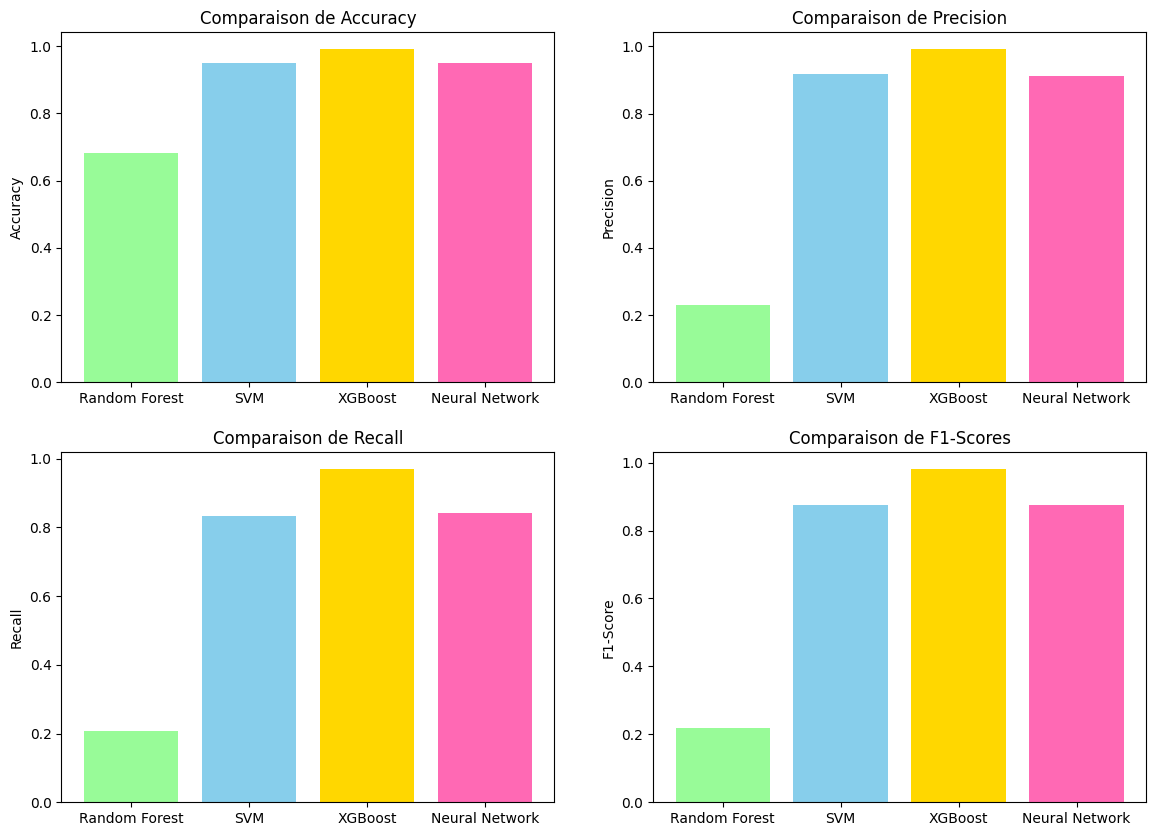

In [24]:
# VOTRE CODE ICI - Section 11.1
# import pandas as pd
# results = []
# # Remplir en fonction des métriques calculées plus haut
# # results.append({'Model': 'Random Forest', 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-Score': ...})
# # results.append({'Model': 'SVM', 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-Score': ...})
# # if xgb_predictions is not None: results.append({'Model': 'XGBoost', 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-Score': ...})
# # results.append({'Model': 'Neural Network', 'Accuracy': ..., 'Precision': ..., 'Recall': ..., 'F1-Score': ...})
# results_df = pd.DataFrame(results)
# display(results_df)
# # Graphique comparatif des F1-scores (optionnel)
# # import matplotlib.pyplot as plt
# # plt.figure()
# # plt.bar(results_df['Model'], results_df['F1-Score'])
# # plt.title('Comparaison des F1-scores')
# # plt.ylabel('F1-Score')
# # plt.show()

# Affichage des résultats pour chaques modèles
results = []

results.append({
    'Model': 'Random Forest',
    'Accuracy' : round(accuracy_score(y_test, rf_predictions), 4), 
    'Precision' : round(precision_score(y_test, rf_predictions), 4), 
    'Recall' : round(recall_score(y_test, rf_predictions), 4), 
    'F1-Score' : round(f1_score(y_test, rf_predictions), 4)
})

results.append({
    'Model' : 'SVM', 
    'Accuracy' : round(accuracy_score(y_test, svm_predictions), 4), 
    'Precision' : round(precision_score(y_test, svm_predictions), 4), 
    'Recall' : round(recall_score(y_test, svm_predictions), 4), 
    'F1-Score' : round(f1_score(y_test, svm_predictions), 4)
})

results.append({
    'Model' : 'XGBoost', 
    'Accuracy' : round(accuracy_score(y_test, xgb_predictions), 4), 
    'Precision' : round(precision_score(y_test, xgb_predictions), 4), 
    'Recall' : round(recall_score(y_test, xgb_predictions), 4), 
    'F1-Score' : round(f1_score(y_test, xgb_predictions), 4)
})

results.append({
    'Model' : 'Neural Network', 
    'Accuracy' : round(accuracy_score(y_test, nn_predictions), 4), 
    'Precision' : round(precision_score(y_test, nn_predictions), 4), 
    'Recall' : round(recall_score(y_test, nn_predictions), 4), 
    'F1-Score' : round(f1_score(y_test, nn_predictions), 4)
})

results_df = pd.DataFrame(results)
display(results_df)

# Graphiques des résultats
plt.figure(1, figsize=(14, 10))

colors = {
    'Random Forest': 'palegreen',
    'SVM': 'skyblue',
    'XGBoost': 'gold',
    'Neural Network': 'hotpink'
}

plt.subplot(2, 2, 1)
plt.bar(results_df['Model'], results_df['Accuracy'], color=[colors[m] for m in results_df['Model']])
plt.title('Comparaison de Accuracy')
plt.ylabel('Accuracy')

plt.subplot(2, 2, 2)
plt.bar(results_df['Model'], results_df['Precision'], color=[colors[m] for m in results_df['Model']])
plt.title('Comparaison de Precision')
plt.ylabel('Precision')

plt.subplot(2, 2, 3)
plt.bar(results_df['Model'], results_df['Recall'], color=[colors[m] for m in results_df['Model']])
plt.title('Comparaison de Recall')
plt.ylabel('Recall')

plt.subplot(2, 2, 4)
plt.bar(results_df['Model'], results_df['F1-Score'], color=[colors[m] for m in results_df['Model']])
plt.title('Comparaison de F1-Scores')
plt.ylabel('F1-Score')


## 12. Validation croisée

In [ ]:
# VOTRE CODE ICI - Section 12.1
# from sklearn.model_selection import cross_val_score
# # Exemple avec Random Forest (remplacez par votre meilleur modèle)
# # scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
# # print(f"Validation croisée - F1-Score: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(rf_model, x_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f'Validation croisée - F1-Score - Random Forest : {rf_scores.mean():.4f} (+-/ {rf_scores.std() * 2:.4f})')

svm_scores = cross_val_score(svm_model, x_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f'Validation croisée - F1-Score - SVM : {svm_scores.mean():.4f} (+-/ {svm_scores.std() * 2:.4f})')

xgb_scores = cross_val_score(xgb_model, x_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f'Validation croisée - F1-Score - XGBoost : {xgb_scores.mean():.4f} (+-/ {xgb_scores.std() * 2:.4f})')

nn_scores = cross_val_score(nn_model, x_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f'Validation croisée - F1-Score - Neural Network : {nn_scores.mean():.4f} (+-/ {nn_scores.std() * 2:.4f})')

## 13. Optimisation des hyperparamètres (Grid Search)

In [ ]:
# # VOTRE CODE ICI - Section 13.1
# # from sklearn.model_selection import GridSearchCV
# # from sklearn.ensemble import RandomForestClassifier
# # param_grid = {
# #     'n_estimators': [50, 100, 200],
# #     'max_depth': [5, 10, None],
# #     'min_samples_split': [2, 5, 10]
# # }
# # grid_search = GridSearchCV(
# #     RandomForestClassifier(random_state=42),
# #     param_grid,
# #     cv=3,
# #     scoring='f1',
# #     n_jobs=-1
# # )
# # grid_search.fit(X_train, y_train)
# # print("Meilleurs paramètres:", grid_search.best_params_)
# # print("Meilleur score CV:", grid_search.best_score_)
# # best_rf = grid_search.best_estimator_
# # best_rf_pred = best_rf.predict(X_test)

# from sklearn.model_selection import GridSearchCV

# # GridSearch Random Forest
# param_grid_rf = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, None],
#     'max_features': ['sqrt', 'log2'],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 5, 10]
# }

# grid_search = GridSearchCV(
#     RandomForestClassifier(random_state=42),
#     param_grid_rf,
#     cv=3,
#     scoring='f1',
#     n_jobs=-1
# )

# grid_search.fit(x_train, y_train)
# print('Meilleurs paramètres Random Forest:', grid_search.best_params_)
# print('Meilleur score CV Random Forest:', grid_search.best_score_)

# best_rf = grid_search.best_estimator_
# best_rf_pred = best_rf.predict(x_test)

# # GridSearch SVM
# param_grid_svm = {
#     'C': [0.1, 1, 10],
#     'kernel': ['linear', 'rbf', 'poly'],
#     'gamma': ['scale', 'auto']
# }

# grid_search_svm = GridSearchCV(
#     SVC(random_state=42),
#     param_grid_svm,
#     cv=3,
#     scoring='f1',
#     n_jobs=-1
# )

# grid_search_svm.fit(x_train, y_train)
# print("Meilleurs paramètres SVM:", grid_search_svm.best_params_)
# print("Meilleur score CV SVM:", grid_search_svm.best_score_)

# best_svm = grid_search_svm.best_estimator_
# best_svm_pred = best_svm.predict(x_test)

# # GridSearch XGBoost
# param_grid_xgb = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 5, 10],
#     'learning_rate': [0.01, 0.1, 0.3],
#     'subsample': [0.7, 1.0],
#     'colsample_bytree': [0.7, 1.0]
# }

# grid_search_xgb = GridSearchCV(
#     XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
#     param_grid_xgb,
#     cv=3,
#     scoring='f1',
#     n_jobs=-1
# )

# grid_search_xgb.fit(x_train, y_train)
# print("Meilleurs paramètres XGBoost:", grid_search_xgb.best_params_)
# print("Meilleur score CV XGBoost:", grid_search_xgb.best_score_)

# best_xgb = grid_search_xgb.best_estimator_
# best_xgb_pred = best_xgb.predict(x_test)

# # GridSearch Neural Network
# param_grid_nn = {
#     'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
#     'activation': ['tanh', 'relu'],
#     'solver': ['adam', 'sgd'],
#     'alpha': [0.0001, 0.001, 0.01],  # régularisation L2
#     'learning_rate': ['constant', 'adaptive']
# }

# grid_search_nn = GridSearchCV(
#     MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
#     param_grid_nn,
#     cv=3,
#     scoring='f1',
#     n_jobs=-1
# )

# grid_search_nn.fit(x_train, y_train)
# print("Meilleurs paramètres NN:", grid_search_nn.best_params_)
# print("Meilleur score CV NN:", grid_search_nn.best_score_)

# best_nn = grid_search_nn.best_estimator_
# best_nn_pred = best_nn.predict(x_test)

## 14. Analyse des erreurs

In [ ]:
# VOTRE CODE ICI - Section 14.1
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix
# # Exemple: matrice de confusion pour le meilleur modèle (remplacez best_rf_pred)
# # cm = confusion_matrix(y_test, best_rf_pred)
# # plt.figure(figsize=(8, 6))
# # sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
# #             xticklabels=['Non-Trending', 'Trending'],
# #             yticklabels=['Non-Trending', 'Trending'])
# # plt.title('Matrice de Confusion - Meilleur Modèle')
# # plt.ylabel('Valeurs Réelles')
# # plt.xlabel('Prédictions')
# # plt.show()

In [ ]:
# VOTRE CODE ICI - Section 14.2
# # Identifier des exemples mal classifiés (adapter selon le modèle choisi)
# # errors_mask = (y_test != best_rf_pred)
# # error_indices = X_test[errors_mask].index
# # print("Exemples de vidéos mal classifiées:")
# # for idx in list(error_indices)[:5]:
# #     real_label = y_test.loc[idx]
# #     predicted_label = best_rf_pred[list(error_indices).index(idx)]  # à adapter si nécessaire
# #     print(f"Index {idx}: Réel={real_label}, Prédit={predicted_label}")

## 15. Sauvegarde & conclusions

In [ ]:
# VOTRE CODE ICI - Section 15.1
# import joblib
# # Remplacez 'best_rf' / 'scaler' par vos objets
# # joblib.dump(best_model, 'best_youtube_classifier.pkl')
# # joblib.dump(scaler, 'feature_scaler.pkl')
# # print("Modèle et scaler sauvegardés avec succès!")

### Conclusions à rédiger

1. **Meilleur modèle**  
   - Modèle: *[À compléter]*  
   - Performances: *[À compléter]*  
   - Raisons: *[À compléter]*

2. **Variables les plus importantes**  
   - *[À compléter]*

3. **Limitations**  
   - *[À compléter]*

4. **Améliorations suggérées**  
   - *[À compléter]*

5. **Apprentissages**  
   - *[À compléter]*

---
## Guide de testing pour les étudiants

**Comment tester vos implémentations :**
1. **Vérifications de base** : `.shape`, `.info()`, `.head()`  
2. **Validation des features** : pas de NaN, ratios entre 0 et 1, plages temporelles correctes  
3. **Validation des modèles** : prédictions binaires {0,1}, longueurs cohérentes, comparaisons rigoureuses  
4. **Tests de cohérence** : scores réalistes, F1 entre précision et rappel, impact de la normalisation  
5. **Debugging** : augmenter `max_iter` si nécessaire, vérifier entrées/sorties et dimensions